In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
merged = pd.read_csv(r"C:\Users\HP\Desktop\Data Science\Transit Delay and Commute Predictor\data\merged_2024.csv", parse_dates=["datetime", "hour_ts"])


In [9]:
merged["hour"] = merged["datetime"].dt.hour
merged["month"] = merged["datetime"].dt.month

sns.set_theme(style="whitegrid")

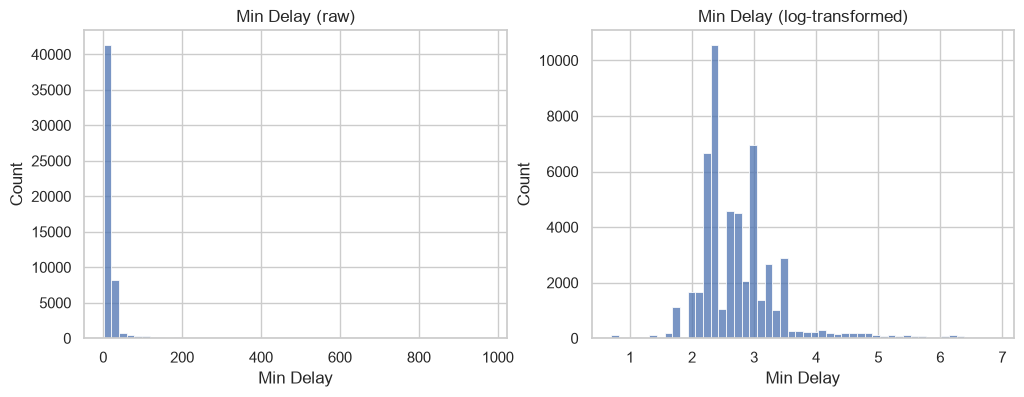

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(merged["Min Delay"], bins=50, ax=axes[0])
axes[0].set_title("Min Delay (raw)")

sns.histplot(np.log1p(merged["Min Delay"]), bins=50, ax=axes[1])
axes[1].set_title("Min Delay (log-transformed)")

plt.show()

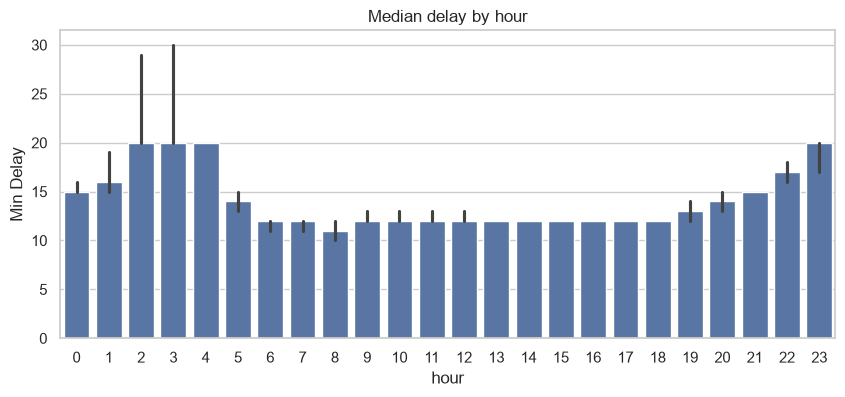

In [11]:
plt.figure(figsize=(10, 4))
sns.barplot(data=merged, x="hour", y="Min Delay", estimator="median")
plt.title("Median delay by hour")
plt.show()

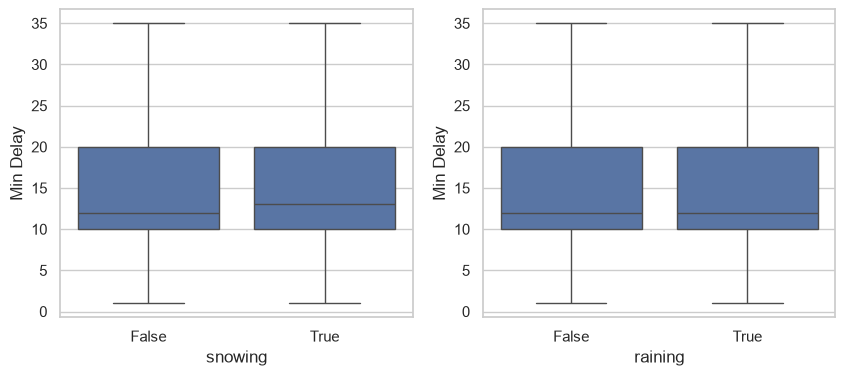

In [12]:
merged["snowing"] = merged["snowfall"] > 0
merged["raining"] = merged["rain"] > 0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=merged, x="snowing", y="Min Delay", ax=axes[0], showfliers=False)
sns.boxplot(data=merged, x="raining", y="Min Delay", ax=axes[1], showfliers=False)
plt.show()

In [13]:
df = merged.copy()

In [17]:
# Time features
df["day_of_week"] = df["datetime"].dt.dayofweek       # 0 = Monday
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["is_rush_hour"] = df["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
df["is_night"] = df["hour"].isin([22, 23, 0, 1, 2, 3, 4]).astype(int)

# Weather features
df["is_snowing"] = (df["snowfall"] > 0).astype(int)
df["is_raining"] = (df["rain"] > 0).astype(int)
df["is_freezing"] = (df["temperature_2m"] < 0).astype(int)

# Target
df["log_delay"] = np.log1p(df["Min Delay"])

# Check the new columns
print(df[["hour", "day_of_week", "is_weekend", "is_rush_hour", "is_night",
          "is_snowing", "is_raining", "is_freezing", "log_delay"]].head())

   hour  day_of_week  is_weekend  is_rush_hour  is_night  is_snowing  \
0     2            0           0             0         1           1   
1     2            0           0             0         1           1   
2     3            0           0             0         1           1   
3     4            0           0             0         1           1   
4     4            0           0             0         1           1   

   is_raining  is_freezing  log_delay  
0           0            1   2.397895  
1           0            1   3.044522  
2           0            1   2.197225  
3           0            1   3.044522  
4           0            1   3.091042  


In [18]:
print(df["Route"].nunique())
print(df["Incident"].nunique())
print(df["Route"].value_counts().head(10))

240
12
Route
32     1659
52     1581
36     1453
35     1274
29     1273
63     1056
95      981
102     978
85      920
96      876
Name: count, dtype: int64


In [19]:
print(df["Incident"].value_counts())

Incident
Mechanical                          19480
Operations - Operator                9783
Diversion                            4028
Collision - TTC                      3761
Security                             3643
Emergency Services                   2632
Utilized Off Route                   2592
Cleaning - Unsanitary                2329
Vision                               1907
General Delay                        1477
Investigation                        1019
Road Blocked - NON-TTC Collision      164
Name: count, dtype: int64


In [20]:
df["Route"] = df["Route"].astype(str)

top_routes = df["Route"].value_counts().head(30).index
df["route_group"] = df["Route"].where(df["Route"].isin(top_routes), "Other")

print(df["route_group"].value_counts().head())
print("Share of rows in 'Other':", (df["route_group"] == "Other").mean().round(2))

route_group
Other    27116
32        1659
52        1581
36        1453
35        1274
Name: count, dtype: int64
Share of rows in 'Other': 0.51


In [21]:
numeric_features = ["hour", "day_of_week", "is_weekend", "is_rush_hour", "is_night",
                    "temperature_2m", "precipitation", "rain", "snowfall",
                    "wind_speed_10m", "is_snowing", "is_raining", "is_freezing"]

X = pd.get_dummies(df[numeric_features + ["Incident", "route_group"]],
                   columns=["Incident", "route_group"], drop_first=True)
y = df["log_delay"]

print(X.shape)

(52815, 54)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(42252, 54) (10563, 54)


In [23]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score

In [24]:
baseline_log = y_train.median()
baseline_pred = np.full(len(y_test), baseline_log)

# Convert back to minutes to judge the error in human terms
mae_base = mean_absolute_error(np.expm1(y_test), np.expm1(baseline_pred))
print("Baseline MAE (minutes):", round(mae_base, 2))
print("Baseline R2 (log scale):", round(r2_score(y_test, baseline_pred), 3))

Baseline MAE (minutes): 14.91
Baseline R2 (log scale): -0.084


In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(np.expm1(y_test), np.expm1(pred_lr))
print("Linear MAE (minutes):", round(mae_lr, 2))
print("Linear R2 (log scale):", round(r2_score(y_test, pred_lr), 3))

Linear MAE (minutes): 12.65
Linear R2 (log scale): 0.473


In [27]:
from sklearn.ensemble import RandomForestRegressor

In [28]:
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                           n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(np.expm1(y_test), np.expm1(pred_rf))
print("Random forest MAE (minutes):", round(mae_rf, 2))
print("Random forest R2 (log scale):", round(r2_score(y_test, pred_rf), 3))

Random forest MAE (minutes): 11.47
Random forest R2 (log scale): 0.528


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

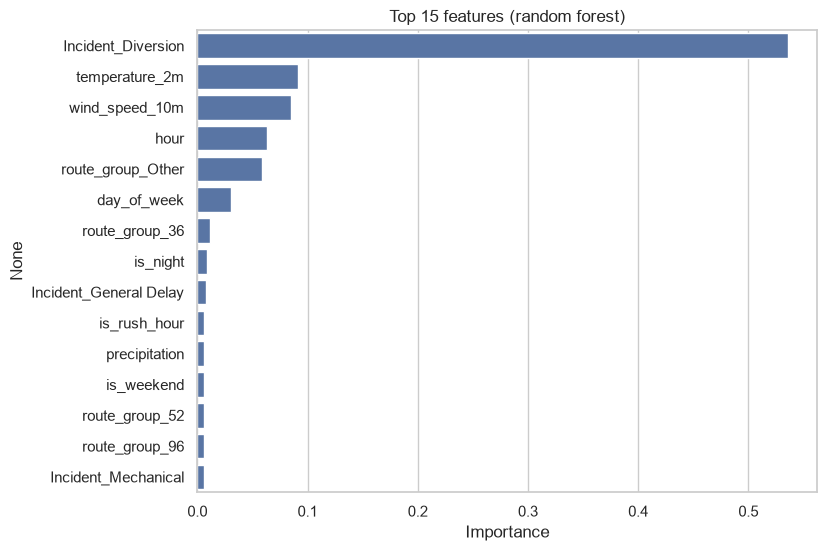

In [30]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=top.values, y=top.index)
plt.title("Top 15 features (random forest)")
plt.xlabel("Importance")
plt.show()

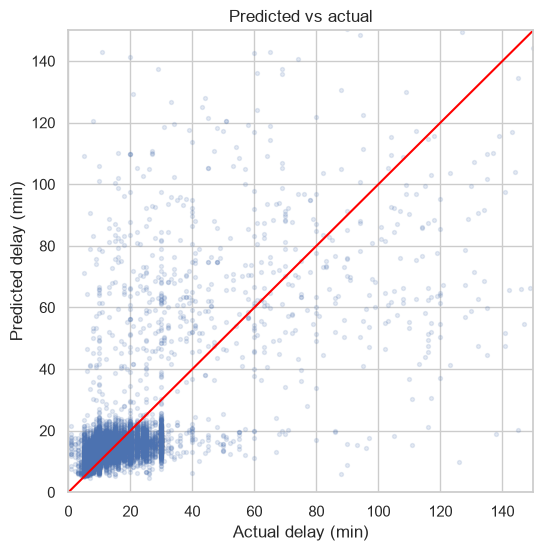

In [31]:
plt.figure(figsize=(6, 6))
plt.scatter(np.expm1(y_test), np.expm1(pred_rf), alpha=0.15, s=8)
plt.plot([0, 150], [0, 150], color="red")
plt.xlim(0, 150)
plt.ylim(0, 150)
plt.xlabel("Actual delay (min)")
plt.ylabel("Predicted delay (min)")
plt.title("Predicted vs actual")
plt.show()

In [32]:
from sklearn.inspection import permutation_importance

In [33]:
# Importance measured on the TEST set, which is less biased
perm = permutation_importance(rf, X_test, y_test, n_repeats=5,
                              random_state=42, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)
print(perm_s.head(10))

Incident_Diversion        0.840915
route_group_Other         0.106508
hour                      0.069485
route_group_36            0.024851
is_night                  0.024086
temperature_2m            0.018426
Incident_General Delay    0.018330
wind_speed_10m            0.015262
route_group_52            0.010035
route_group_63            0.008846
dtype: float64


In [34]:
# Ablation: retrain without any weather columns
weather_cols = ["temperature_2m", "precipitation", "rain", "snowfall",
                "wind_speed_10m", "is_snowing", "is_raining", "is_freezing"]
X_tr_nw = X_train.drop(columns=weather_cols)
X_te_nw = X_test.drop(columns=weather_cols)

rf_nw = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                              n_jobs=-1, random_state=42)
rf_nw.fit(X_tr_nw, y_train)
pred_nw = rf_nw.predict(X_te_nw)

print("No-weather MAE:", round(mean_absolute_error(np.expm1(y_test), np.expm1(pred_nw)), 2))
print("No-weather R2:", round(r2_score(y_test, pred_nw), 3))

No-weather MAE: 11.75
No-weather R2: 0.521


In [35]:
# Train on Jan-Sep, test on Oct-Dec
cutoff = pd.Timestamp("2024-10-01")
train_mask = df["datetime"] < cutoff
test_mask = ~train_mask

Xtr, Xte = X[train_mask], X[test_mask]
ytr, yte = y[train_mask], y[test_mask]
print(Xtr.shape, Xte.shape)

def evaluate(cols, label):
    m = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                              n_jobs=-1, random_state=42)
    m.fit(Xtr[cols], ytr)
    p = m.predict(Xte[cols])
    print(label, "MAE:", round(mean_absolute_error(np.expm1(yte), np.expm1(p)), 2),
          "R2:", round(r2_score(yte, p), 3))

all_cols = list(X.columns)
no_weather_cols = [c for c in all_cols if c not in weather_cols]

evaluate(all_cols, "With weather   ")
evaluate(no_weather_cols, "Without weather")

(40142, 54) (12673, 54)
With weather    MAE: 11.68 R2: 0.484
Without weather MAE: 11.72 R2: 0.489


In [36]:
# Final model: all data, no weather
final_cols = no_weather_cols
final_model = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                                    n_jobs=-1, random_state=42)
final_model.fit(X[final_cols], y)

def predict_delay(route, incident, hour, day_of_week):
    row = pd.DataFrame(0, index=[0], columns=final_cols)
    row["hour"] = hour
    row["day_of_week"] = day_of_week
    row["is_weekend"] = int(day_of_week >= 5)
    row["is_rush_hour"] = int(hour in [7, 8, 9, 16, 17, 18])
    row["is_night"] = int(hour in [22, 23, 0, 1, 2, 3, 4])

    inc_col = f"Incident_{incident}"
    if inc_col in row.columns:
        row[inc_col] = 1

    route_col = f"route_group_{route}"
    if route_col in row.columns:
        row[route_col] = 1
    # routes outside the top 30 -> "Other" (all route columns stay 0 after drop_first)

    return round(float(np.expm1(final_model.predict(row)[0])), 1)

print(predict_delay("36", "Mechanical", 8, 1))
print(predict_delay("36", "Diversion", 8, 1))
print(predict_delay("36", "Diversion", 2, 5))

6.7
65.1
87.8


In [37]:
print(df.groupby("Incident")["Min Delay"].median().sort_values())
print(df[(df["Route"] == "36") & (df["Incident"] == "Mechanical")]["Min Delay"].describe())


Incident
Collision - TTC                     10.0
Utilized Off Route                  10.0
Emergency Services                  12.0
Cleaning - Unsanitary               12.0
Operations - Operator               12.0
Mechanical                          12.0
Security                            12.0
Investigation                       12.0
Vision                              12.0
General Delay                       20.0
Road Blocked - NON-TTC Collision    20.0
Diversion                           70.0
Name: Min Delay, dtype: float64
count    685.000000
mean       7.302190
std        3.211922
min        1.000000
25%        6.000000
50%        6.000000
75%        8.000000
max       30.000000
Name: Min Delay, dtype: float64


In [38]:
top_routes_list = list(top_routes)

def predict_delay(route, incident, hour, day_of_week):
    route = str(route)
    if route not in top_routes_list:
        route = "Other"          # map unknown routes to the Other group

    row = pd.DataFrame(0, index=[0], columns=final_cols)
    row["hour"] = hour
    row["day_of_week"] = day_of_week
    row["is_weekend"] = int(day_of_week >= 5)
    row["is_rush_hour"] = int(hour in [7, 8, 9, 16, 17, 18])
    row["is_night"] = int(hour in [22, 23, 0, 1, 2, 3, 4])

    for col in (f"Incident_{incident}", f"route_group_{route}"):
        if col in row.columns:
            row[col] = 1

    return round(float(np.expm1(final_model.predict(row)[0])), 1)

print(predict_delay("36", "Mechanical", 8, 1))
print(predict_delay("999", "Mechanical", 8, 1))   # unknown route -> Other
print([c for c in X.columns if c.startswith("Incident_")])   # which incident was dropped?

6.7
11.2
['Incident_Collision - TTC', 'Incident_Diversion', 'Incident_Emergency Services', 'Incident_General Delay', 'Incident_Investigation', 'Incident_Mechanical', 'Incident_Operations - Operator', 'Incident_Road Blocked - NON-TTC Collision', 'Incident_Security', 'Incident_Utilized Off Route', 'Incident_Vision']


In [39]:
import os
os.makedirs("../images", exist_ok=True)
# re-run each plot cell, then add this line right after plt.show() or before it:
# plt.savefig("../images/delay_distribution.png", dpi=150, bbox_inches="tight")

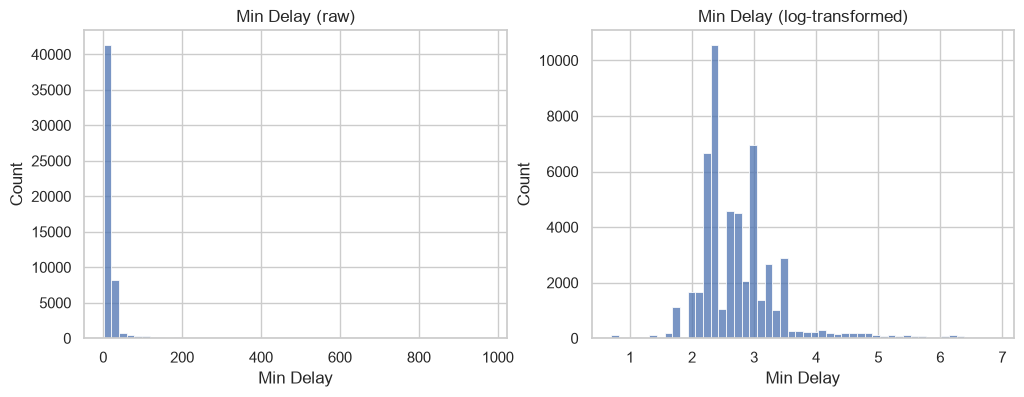

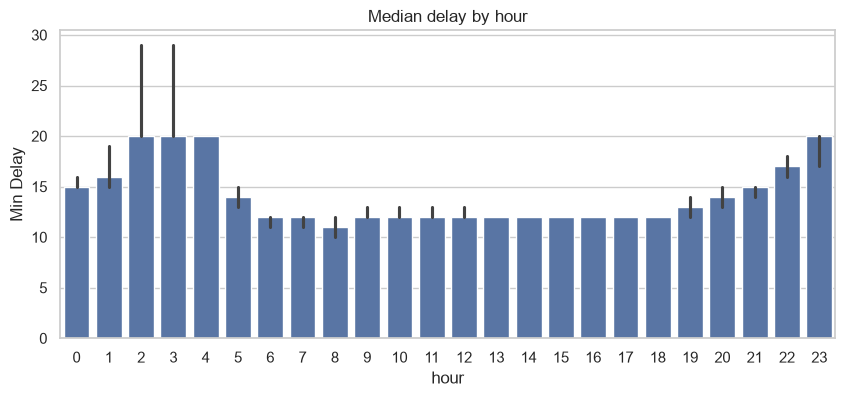

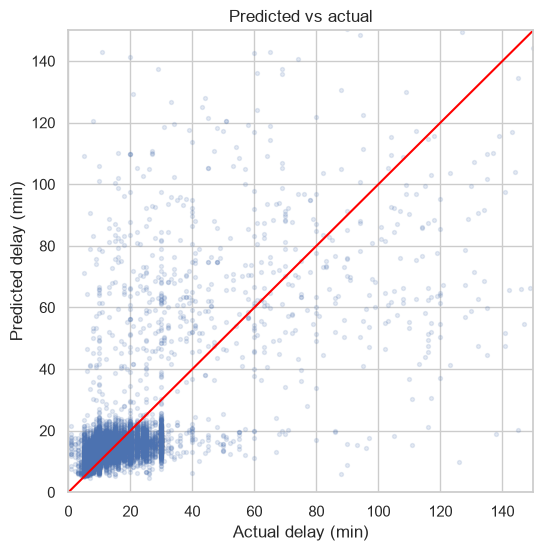

['delay_by_hour.png', 'delay_distribution.png', 'predicted_vs_actual.png']


In [40]:
import os
os.makedirs("../images", exist_ok=True)

# 1. Raw vs log-transformed distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Min Delay"], bins=50, ax=axes[0])
axes[0].set_title("Min Delay (raw)")
sns.histplot(np.log1p(df["Min Delay"]), bins=50, ax=axes[1])
axes[1].set_title("Min Delay (log-transformed)")
plt.savefig("../images/delay_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# 2. Median delay by hour
plt.figure(figsize=(10, 4))
sns.barplot(data=df, x="hour", y="Min Delay", estimator="median")
plt.title("Median delay by hour")
plt.savefig("../images/delay_by_hour.png", dpi=150, bbox_inches="tight")
plt.show()

# 3. Predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(np.expm1(y_test), np.expm1(pred_rf), alpha=0.15, s=8)
plt.plot([0, 150], [0, 150], color="red")
plt.xlim(0, 150)
plt.ylim(0, 150)
plt.xlabel("Actual delay (min)")
plt.ylabel("Predicted delay (min)")
plt.title("Predicted vs actual")
plt.savefig("../images/predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

print(os.listdir("../images"))